# Project 6: Wind Power Data Analytics

This notebook demonstrates a complete workflow for **wind power data analytics** using sample datasets.

The project uses:
- wind and weather measurements
- turbine operational data

The goals are to:
- analyze the relationship between **wind speed and power output**
- understand the **turbine power curve**
- estimate **generation variability**
- build a simple model to predict wind turbine power output

A **Decision Tree Regressor** is used in this notebook. This model is different from Random Forest and Gradient Boosting, simple to explain, and suitable for teaching because it can capture nonlinear behavior such as the turbine power curve.

The notebook demonstrates a full wind power analytics workflow:
- loading and cleaning multiple datasets
- merging weather and turbine operational data
- analyzing the wind speed to power relationship
- visualizing the turbine power curve
- measuring generation variability
- building a baseline forecast
- training a Decision Tree model
- evaluating and visualizing the results


## Step 1. Import the Python libraries

In this first step, the Python libraries that will be used throughout the notebook are imported. These libraries are needed for data manipulation, visualization, machine learning, and evaluation. The selected libraries are widely used in practical data analysis projects.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


## Step 2. Load the datasets

In this step, the wind weather dataset and the turbine operational dataset are loaded. In real-world wind energy projects, environmental measurements and turbine measurements often come from different systems and need to be combined before analysis.


In [2]:
BASE_URL = "https://raw.githubusercontent.com/tskaneva/bip_2026_big_data_and_ai_in_res/main/data"

weather_df = pd.read_csv(f"{BASE_URL}/sample_wind_weather_data.csv")
turbine_df = pd.read_csv(f"{BASE_URL}/sample_wind_turbine_data.csv")

## Step 3. Display the first rows and basic information

In this step, the first rows and structural information of both datasets are displayed. This helps confirm that the files were loaded correctly and provides an initial understanding of the available columns and their data types.


In [3]:
print("WEATHER DATA")
print(weather_df.head())
print(weather_df.info())

print("\nTURBINE DATA")
print(turbine_df.head())
print(turbine_df.info())


WEATHER DATA
             timestamp  wind_speed_m_s  wind_direction_deg  temperature_c  \
0  2023-01-01 00:00:00        7.880051          246.778241       8.549006   
1  2023-01-01 01:00:00        8.110975          137.942446       6.682502   
2  2023-01-01 02:00:00       10.862333          183.607927       7.320760   
3  2023-01-01 03:00:00        7.038461          205.746361       8.119917   
4  2023-01-01 04:00:00        7.842327          247.175144       4.233444   

   air_density_kg_m3  turbulence_intensity  
0           1.238796              0.096170  
1           1.251185              0.074884  
2           1.250529              0.096434  
3           1.251341              0.088920  
4           1.265202              0.091182  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2162 entries, 0 to 2161
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   timestamp             2162 non-null   obj

## Step 4. Convert the timestamp columns to datetime format

In this step, the timestamp columns are converted to datetime format. This is required because sorting, merging, resampling, and extracting time-based features depend on proper datetime values.


In [4]:
weather_df["timestamp"] = pd.to_datetime(weather_df["timestamp"])
turbine_df["timestamp"] = pd.to_datetime(turbine_df["timestamp"])


## Step 5. Sort the datasets chronologically

In this step, the datasets are sorted by time. Time series and operational datasets should always be ordered correctly before analysis.


In [5]:
weather_df = weather_df.sort_values("timestamp").reset_index(drop=True)
turbine_df = turbine_df.sort_values("timestamp").reset_index(drop=True)


## Step 6. Remove duplicate timestamps

In this step, duplicate timestamps are removed. Duplicate measurements can create problems during merging and may distort descriptive analysis and model training.


In [6]:
weather_df = weather_df.drop_duplicates(subset="timestamp")
turbine_df = turbine_df.drop_duplicates(subset="timestamp")


## Step 7. Check missing values

In this step, missing values are counted in both datasets. Missing values are common in sensor-based wind energy systems, so they should be identified early in the workflow.


In [7]:
print("Missing values in weather data:")
print(weather_df.isna().sum())

print("\nMissing values in turbine data:")
print(turbine_df.isna().sum())


Missing values in weather data:
timestamp               0
wind_speed_m_s          8
wind_direction_deg      0
temperature_c           8
air_density_kg_m3       0
turbulence_intensity    0
dtype: int64

Missing values in turbine data:
timestamp           0
power_output_kw     8
rotor_speed_rpm     8
generator_temp_c    0
turbine_status      0
dtype: int64


## Step 8. Set the timestamp as the index

In this step, the timestamp column becomes the index. This makes time-based alignment and resampling easier to perform.


In [8]:
weather_df = weather_df.set_index("timestamp")
turbine_df = turbine_df.set_index("timestamp")


## Step 9. Resample both datasets to hourly frequency

In this step, the datasets are resampled to hourly frequency. The sample data is already hourly, but this step demonstrates a common operation used to ensure that both sources follow the same time interval.


In [9]:
weather_df = weather_df.resample("h").mean(numeric_only=True)
turbine_numeric = turbine_df.select_dtypes(include=[np.number]).resample("h").mean()
turbine_status = turbine_df[["turbine_status"]].resample("h").agg(lambda x: x.mode().iloc[0] if not x.mode().empty else x.iloc[0])

turbine_df = turbine_numeric.join(turbine_status, how="left")


## Step 10. Merge the weather and turbine datasets

In this step, the datasets are merged by timestamp. This produces a unified dataset where each hour contains both weather variables and turbine operational variables.


In [10]:
df = weather_df.join(turbine_df, how="inner")
print(df.head())
print("\nMerged dataset shape:", df.shape)


                     wind_speed_m_s  wind_direction_deg  temperature_c  \
timestamp                                                                
2023-01-01 00:00:00        7.880051          246.778241       8.549006   
2023-01-01 01:00:00        8.110975          137.942446       6.682502   
2023-01-01 02:00:00       10.862333          183.607927       7.320760   
2023-01-01 03:00:00        7.038461          205.746361       8.119917   
2023-01-01 04:00:00        7.842327          247.175144       4.233444   

                     air_density_kg_m3  turbulence_intensity  power_output_kw  \
timestamp                                                                       
2023-01-01 00:00:00           1.238796              0.096170       284.000143   
2023-01-01 01:00:00           1.251185              0.074884       397.314233   
2023-01-01 02:00:00           1.250529              0.096434      1347.506905   
2023-01-01 03:00:00           1.251341              0.088920       183.08895

## Step 11. Handle missing values after merging

In this step, missing values are handled using forward fill and backward fill. For time series sensor data, this is often a practical method because nearby values are usually more meaningful than a global mean.


In [11]:
print("Missing values before filling:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nMissing values after filling:")
print(df.isna().sum())


Missing values before filling:
wind_speed_m_s          8
wind_direction_deg      0
temperature_c           8
air_density_kg_m3       0
turbulence_intensity    0
power_output_kw         8
rotor_speed_rpm         8
generator_temp_c        0
turbine_status          0
dtype: int64

Missing values after filling:
wind_speed_m_s          0
wind_direction_deg      0
temperature_c           0
air_density_kg_m3       0
turbulence_intensity    0
power_output_kw         0
rotor_speed_rpm         0
generator_temp_c        0
turbine_status          0
dtype: int64


## Step 12. Visualize wind speed and power output over time

In this step, the main variables are plotted over time. This helps identify general patterns, variability, and possible abnormal periods.


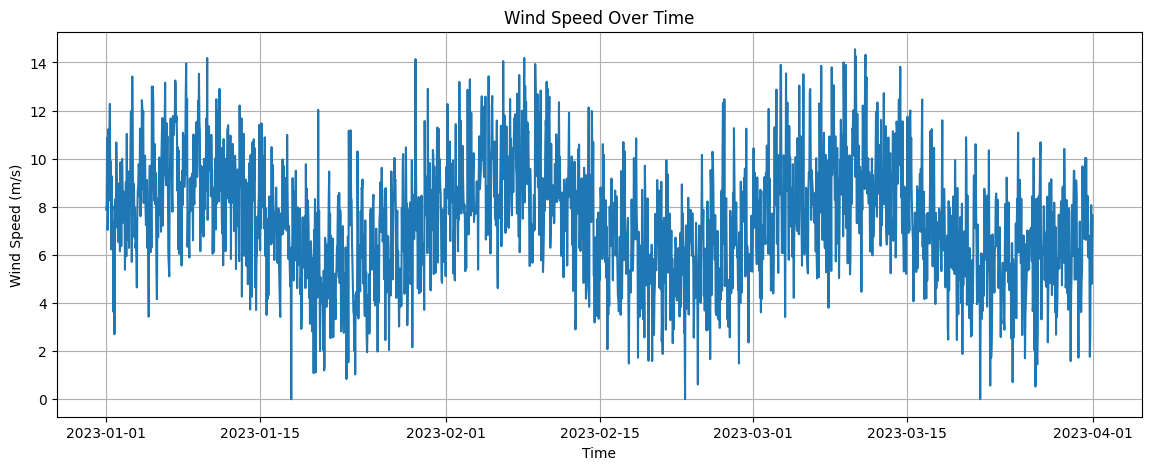

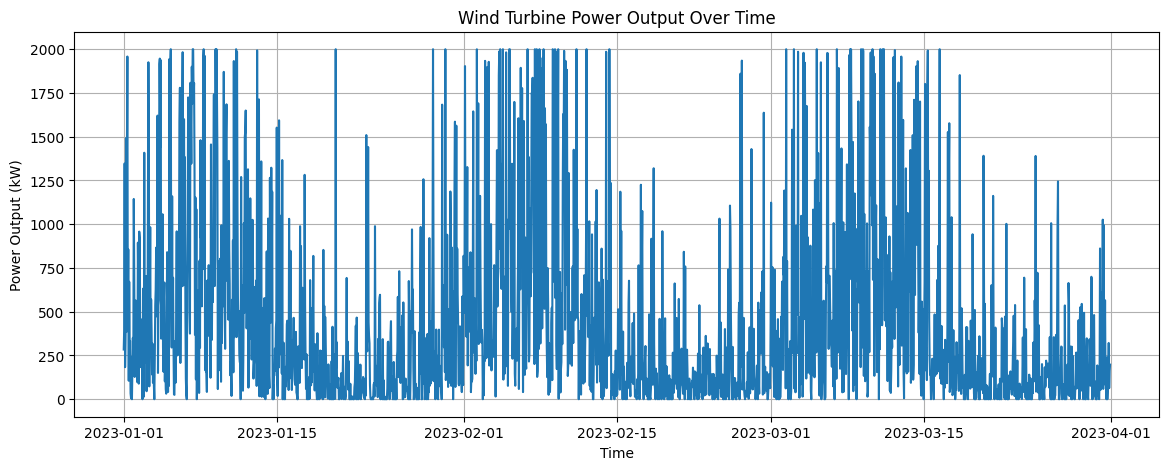

In [12]:
plt.figure(figsize=(14, 5))
plt.plot(df.index, df["wind_speed_m_s"], label="Wind Speed (m/s)")
plt.title("Wind Speed Over Time")
plt.xlabel("Time")
plt.ylabel("Wind Speed (m/s)")
plt.grid(True)
plt.show()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["power_output_kw"], label="Power Output (kW)")
plt.title("Wind Turbine Power Output Over Time")
plt.xlabel("Time")
plt.ylabel("Power Output (kW)")
plt.grid(True)
plt.show()


## Step 13. Create time-based features

In this step, time-related variables are extracted from the timestamp. Wind behavior and turbine operation can vary with the hour of the day, the day of the week, and the month.


In [13]:
df["hour"] = df.index.hour
df["day_of_week"] = df.index.dayofweek
df["month"] = df.index.month
df["is_weekend"] = (df["day_of_week"] >= 5).astype(int)


## Step 14. Create cyclical time features

In this step, the hour and day-of-week variables are transformed into sine and cosine values. This is useful because these variables are cyclical, and cyclical encoding preserves that structure better than raw integer values.


In [14]:
df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)


## Step 15. Encode turbine status as numbers

In this step, the turbine status values are converted to numeric codes. Machine learning models require numerical input, so categorical operational states must be encoded.


In [15]:
status_mapping = {"idle": 0, "running": 1, "curtailed": 2}
df["turbine_status_code"] = df["turbine_status"].map(status_mapping)


## Step 16. Visualize the turbine power curve

In this step, a scatter plot of wind speed versus power output is created. This plot is one of the most important analyses in wind power systems because it reveals the turbine power curve and shows how power changes with wind speed.


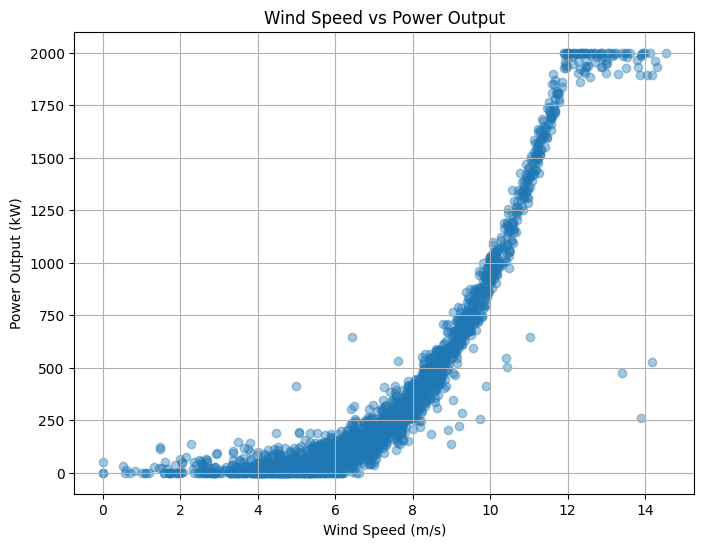

In [16]:
plt.figure(figsize=(8, 6))
plt.scatter(df["wind_speed_m_s"], df["power_output_kw"], alpha=0.4)
plt.title("Wind Speed vs Power Output")
plt.xlabel("Wind Speed (m/s)")
plt.ylabel("Power Output (kW)")
plt.grid(True)
plt.show()


## Step 17. Build an averaged power curve by wind speed bins

In this step, wind speed values are grouped into bins and the average power output in each bin is calculated. This makes the turbine power curve easier to observe and interpret.


wind_speed_bin
(0, 1]        10.297612
(1, 2]        18.088739
(2, 3]        25.275729
(3, 4]        22.527536
(4, 5]        31.004616
(5, 6]        56.195744
(6, 7]       124.861349
(7, 8]       251.692613
(8, 9]       447.732243
(9, 10]      736.428191
(10, 11]    1125.927916
(11, 12]    1641.282965
(12, 13]    1970.745640
(13, 14]    1848.451282
(14, 15]    1775.921179
(15, 16]            NaN
(16, 17]            NaN
(17, 18]            NaN
(18, 19]            NaN
(19, 20]            NaN
(20, 21]            NaN
(21, 22]            NaN
(22, 23]            NaN
(23, 24]            NaN
(24, 25]            NaN
Name: power_output_kw, dtype: float64


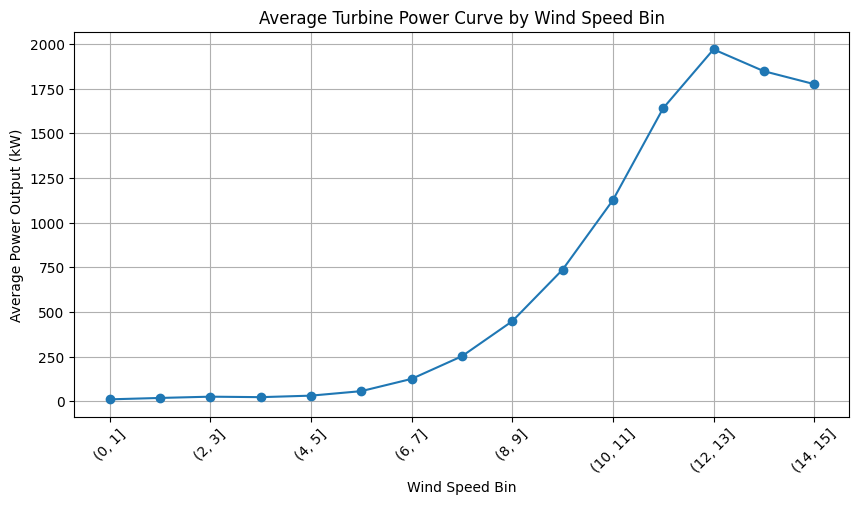

In [17]:
df["wind_speed_bin"] = pd.cut(df["wind_speed_m_s"], bins=np.arange(0, 26, 1))
power_curve = df.groupby("wind_speed_bin", observed=False)["power_output_kw"].mean()

print(power_curve)

plt.figure(figsize=(10, 5))
power_curve.plot(marker="o")
plt.title("Average Turbine Power Curve by Wind Speed Bin")
plt.xlabel("Wind Speed Bin")
plt.ylabel("Average Power Output (kW)")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()


## Step 18. Analyze generation variability

In this step, rolling statistics are used to study variability in wind generation. A rolling mean shows the average recent output, and a rolling standard deviation shows how unstable or variable the output has been.


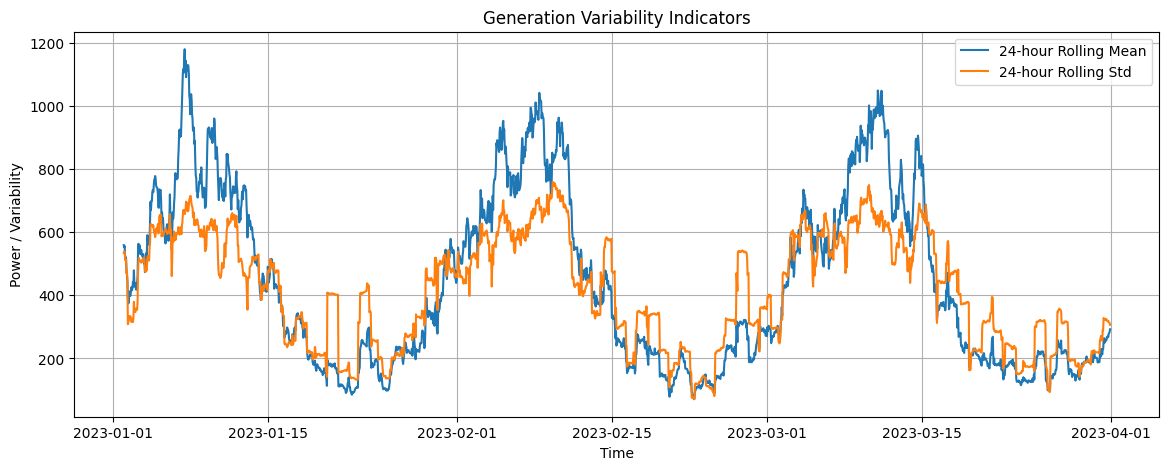

In [18]:
df["power_roll_mean_24"] = df["power_output_kw"].rolling(window=24).mean()
df["power_roll_std_24"] = df["power_output_kw"].rolling(window=24).std()

plt.figure(figsize=(14, 5))
plt.plot(df.index, df["power_roll_mean_24"], label="24-hour Rolling Mean")
plt.plot(df.index, df["power_roll_std_24"], label="24-hour Rolling Std")
plt.title("Generation Variability Indicators")
plt.xlabel("Time")
plt.ylabel("Power / Variability")
plt.legend()
plt.grid(True)
plt.show()


## Step 19. Create lag features from previous power values

In this step, lag features are created from previous turbine power output. Previous values are useful because wind generation often has short-term temporal dependence.

The selected lags are:
- previous 1 hour
- previous 24 hours


In [19]:
df["power_lag_1"] = df["power_output_kw"].shift(1)
df["power_lag_24"] = df["power_output_kw"].shift(24)


## Step 20. Create the prediction target

In this step, the target variable is defined as the next-hour power output. This means the model will use current and past information to forecast wind power one hour ahead.


In [20]:
df["target_power_next_hour"] = df["power_output_kw"].shift(-1)


## Step 21. Remove rows with missing values caused by shifting and rolling

In this step, rows with missing values are removed. Lag features, rolling statistics, and target shifting naturally create missing values at the beginning and end of the dataset.


In [21]:
df = df.dropna()
print("Final dataset shape:", df.shape)
print(df.head())


Final dataset shape: (2132, 24)
                     wind_speed_m_s  wind_direction_deg  temperature_c  \
timestamp                                                                
2023-01-02 00:00:00        7.136456          292.979884       6.829906   
2023-01-02 01:00:00        8.750866          240.043013       7.285912   
2023-01-02 02:00:00        8.978206          301.108163       4.238006   
2023-01-02 03:00:00        6.526215          270.021344       6.209594   
2023-01-02 04:00:00        7.919793          201.436024       3.728645   

                     air_density_kg_m3  turbulence_intensity  power_output_kw  \
timestamp                                                                       
2023-01-02 00:00:00           1.238451              0.076751       127.352339   
2023-01-02 01:00:00           1.255809              0.091184       504.223723   
2023-01-02 02:00:00           1.250166              0.075180       564.258495   
2023-01-02 03:00:00           1.250038      

## Step 22. Define the model input features and target

In this step, the feature columns and the target variable are separated. The selected features include environmental variables, turbine measurements, time variables, and lag features.


In [22]:
feature_columns = [
    "wind_speed_m_s",
    "wind_direction_deg",
    "temperature_c",
    "air_density_kg_m3",
    "turbulence_intensity",
    "rotor_speed_rpm",
    "generator_temp_c",
    "turbine_status_code",
    "hour",
    "day_of_week",
    "month",
    "is_weekend",
    "hour_sin",
    "hour_cos",
    "dow_sin",
    "dow_cos",
    "power_lag_1",
    "power_lag_24",
    "power_roll_mean_24",
    "power_roll_std_24"
]

X = df[feature_columns]
y = df["target_power_next_hour"]


## Step 23. Split the dataset chronologically

In this step, the data is split into training, validation, and testing sets in chronological order. This is important for time-related energy data because future observations should not influence model training.

This notebook uses:
- 70% training data
- 15% validation data
- 15% testing data


In [23]:
n = len(df)

train_end = int(n * 0.70)
val_end = int(n * 0.85)

X_train = X.iloc[:train_end]
y_train = y.iloc[:train_end]

X_val = X.iloc[train_end:val_end]
y_val = y.iloc[train_end:val_end]

X_test = X.iloc[val_end:]
y_test = y.iloc[val_end:]

print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)


Train shape: (1492, 20)
Validation shape: (320, 20)
Test shape: (320, 20)


## Step 24. Build a baseline forecast

In this step, a simple baseline forecast is created. A practical baseline for short-term wind power forecasting is to assume that the next-hour power output will be close to the current-hour power output. This corresponds to using the 1-hour lag of power.


In [24]:
baseline_val_pred = X_val["power_lag_1"]
baseline_test_pred = X_test["power_lag_1"]


## Step 25. Evaluate the baseline forecast

In this step, the baseline forecast is evaluated using standard regression metrics. These values provide a reference that the machine learning model should improve upon.


In [25]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print(model_name)
    print(f"MAE  : {mae:.4f}")
    print(f"RMSE : {rmse:.4f}")
    print(f"R²   : {r2:.4f}")
    print("-" * 30)

evaluate_model(y_val, baseline_val_pred, "Baseline Validation Results")
evaluate_model(y_test, baseline_test_pred, "Baseline Test Results")


Baseline Validation Results
MAE  : 546.6706
RMSE : 744.5608
R²   : -0.5145
------------------------------
Baseline Test Results
MAE  : 217.3275
RMSE : 330.0801
R²   : -0.8098
------------------------------


## Step 26. Train a Decision Tree model

In this step, a Decision Tree Regressor is trained. This model is well suited to this project because wind turbine behavior is highly nonlinear, especially around cut-in, rated, and cut-out regions of the power curve.

The selected parameter values are:
- `max_depth=6`: limits tree complexity and helps reduce overfitting
- `min_samples_split=20`: requires enough samples before splitting
- `random_state=42`: ensures reproducibility


In [26]:
model = DecisionTreeRegressor(
    max_depth=6,
    min_samples_split=20,
    random_state=42
)

model.fit(X_train, y_train)


DecisionTreeRegressor(max_depth=6, min_samples_split=20, random_state=42)

## Step 27. Make validation and test predictions

In this step, the trained model is used to predict wind turbine power for the validation and test sets.


In [27]:
val_pred = model.predict(X_val)
test_pred = model.predict(X_test)


## Step 28. Evaluate the Decision Tree model

In this step, the machine learning model is evaluated using the same metrics as the baseline. This allows a direct comparison between the model and the naive forecast.


In [28]:
evaluate_model(y_val, val_pred, "Decision Tree Validation Results")
evaluate_model(y_test, test_pred, "Decision Tree Test Results")


Decision Tree Validation Results
MAE  : 487.5378
RMSE : 623.7510
R²   : -0.0629
------------------------------
Decision Tree Test Results
MAE  : 174.3456
RMSE : 264.0779
R²   : -0.1584
------------------------------


## Step 29. Visualize actual and predicted power output

In this step, the actual and predicted turbine power values are plotted for part of the test period. This helps assess whether the model follows the real trends and changes in generation.


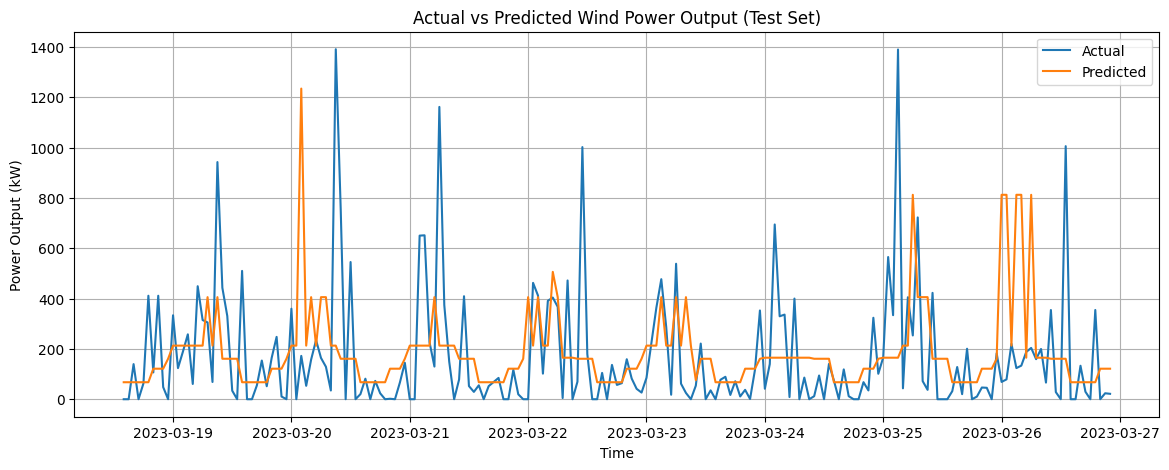

In [29]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], test_pred[:200], label="Predicted")
plt.title("Actual vs Predicted Wind Power Output (Test Set)")
plt.xlabel("Time")
plt.ylabel("Power Output (kW)")
plt.legend()
plt.grid(True)
plt.show()


## Step 30. Compare the baseline and the Decision Tree model

In this step, the baseline and the machine learning model are plotted together. This provides a direct visual comparison between the simple forecasting rule and the trained model.


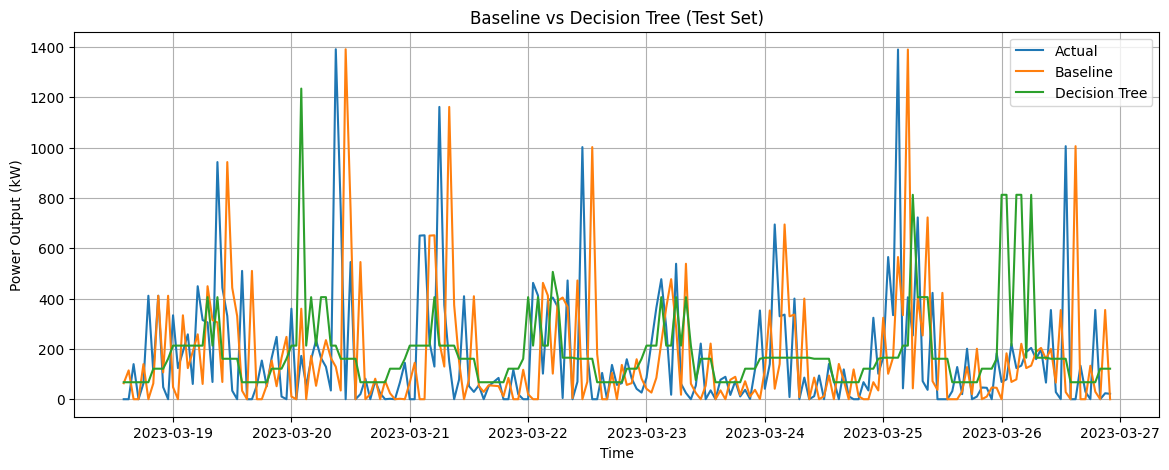

In [30]:
plt.figure(figsize=(14, 5))
plt.plot(y_test.index[:200], y_test.iloc[:200], label="Actual")
plt.plot(y_test.index[:200], baseline_test_pred.iloc[:200], label="Baseline")
plt.plot(y_test.index[:200], test_pred[:200], label="Decision Tree")
plt.title("Baseline vs Decision Tree (Test Set)")
plt.xlabel("Time")
plt.ylabel("Power Output (kW)")
plt.legend()
plt.grid(True)
plt.show()


## Step 31. Display feature importance values

In this step, the feature importance values from the Decision Tree model are displayed. These values help identify which measurements contribute the most to predicting wind power output.


In [31]:
importances = pd.Series(model.feature_importances_, index=feature_columns)
importances = importances.sort_values(ascending=False)

print(importances)


power_roll_mean_24      0.502501
hour_sin                0.198663
hour                    0.069476
turbulence_intensity    0.058829
temperature_c           0.034029
power_lag_24            0.024043
wind_direction_deg      0.023014
rotor_speed_rpm         0.020272
power_lag_1             0.013091
air_density_kg_m3       0.012451
hour_cos                0.009443
is_weekend              0.008330
generator_temp_c        0.008099
wind_speed_m_s          0.007369
dow_cos                 0.005935
power_roll_std_24       0.004454
month                   0.000000
day_of_week             0.000000
turbine_status_code     0.000000
dow_sin                 0.000000
dtype: float64


## Step 32. Visualize feature importance

In this step, the most important features are plotted. This makes the model easier to interpret and helps explain which variables drive wind power behavior in the sample dataset.


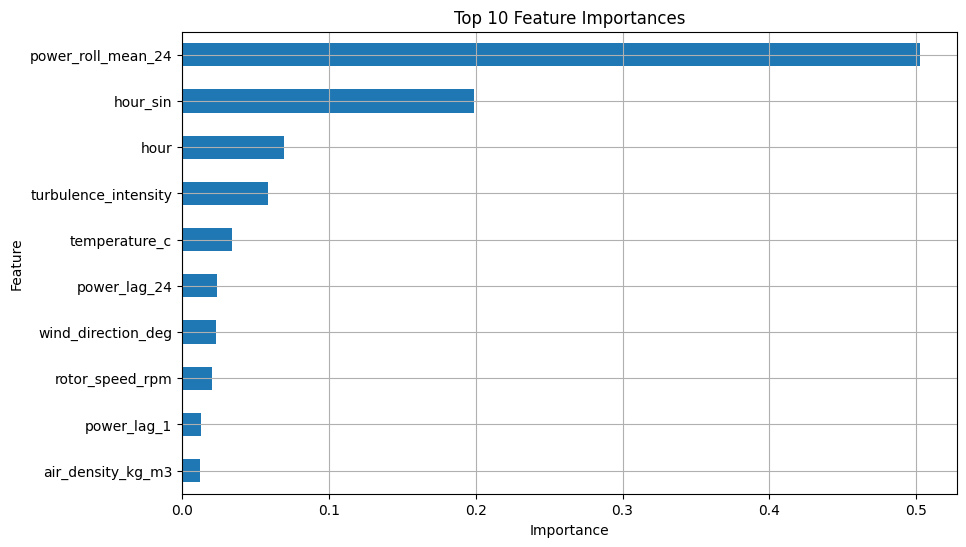

In [32]:
plt.figure(figsize=(10, 6))
importances.head(10).sort_values().plot(kind="barh")
plt.title("Top 10 Feature Importances")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(True)
plt.show()


## Step 33. Calculate MAPE as an additional metric

In this step, the mean absolute percentage error is calculated. This expresses the prediction error in percentage terms. A small constant is used to avoid division by zero.


In [33]:
def mean_absolute_percentage_error(y_true, y_pred):
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    epsilon = 1e-8
    return np.mean(np.abs((y_true - y_pred) / (y_true + epsilon))) * 100

mape_test = mean_absolute_percentage_error(y_test, test_pred)
print(f"Test MAPE: {mape_test:.2f}%")


Test MAPE: 304077272626.44%


## Step 34. Save the prediction results to a CSV file

In this step, the actual values and predictions are saved to a CSV file. This is useful for reporting, further analysis, or creating additional visualizations outside the notebook.


In [34]:
results_df = pd.DataFrame({
    "timestamp": y_test.index,
    "actual_power": y_test.values,
    "baseline_prediction": baseline_test_pred.values,
    "dt_prediction": test_pred
})

results_df.to_csv("wind_power_prediction_results.csv", index=False)
print("Results saved to wind_power_prediction_results.csv")


Results saved to wind_power_prediction_results.csv
